# ThF⁺ X ³Δ₁ with `heff`

We will work with ²³²Th¹⁹F⁺ in X ³Δ₁, v = 0, J = 1–4. In the Hund's case
(c) basis |J, Ω = ±1, F, m_F⟩, these choices give 96 states. Collinear static
fields preserve signed m_F, so the Hamiltonian separates into smaller blocks.

The organizing idea in `heff` is `H = Σ_k c_k M_k`. Each matrix `M_k` contains
the angular-momentum structure of one interaction, while `c_k` contains its
molecular parameter or field strength. We build the matrices once per basis
block and reuse them. A parameter change becomes a weighted sum, a sweep uses
one `np.tensordot` followed by batched `eigh`, and Hellmann–Feynman gives the
derivatives through `∂H/∂knob = Σ M_k` without finite differences.

We use the native API so that the basis, term matrices, and observables stay
visible. After assembling the zero-field Hamiltonian, we calculate Stark and
Zeeman shifts and connect their slopes to g-factors,
induced dipoles, and the Ω-doublet Δg. We then inspect PT-odd and E1 matrix
elements and finish with a 200-point parameter sweep. If the model-file
workflow is new to you, start with the repository [README](../README.md).
The separate [three-isotope field plots](../results/thf-fields-2026-09-08/README.md)
cover broader J = 1–3 scans with their own parameter sets.

The physics source is [HAM](../docs/thf-plus-x3delta1-effective-hamiltonian.md),
and every matrix element carries its citation in `term.cite`. The calculations
show what follows from this effective Hamiltonian and its selected inputs.
Software tests check implementation identities and regressions; they do not
establish that the model is physically complete.

We use the following defaults: n̂ from F to Th
(JILA), e/f by Brown 1975, Zeeman `+μ_B B·G·J` with the body-frame
tensor `G = diag(G_xx, G_yy, G_zz)`, `E = −g μ_B B m_F`,
`Δg = g^u − g^ℓ`, eEDM with no Leanhardt ½.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import heff
from heff import (block_by_mF, build_term_matrices, ctx_from, eigh_batch,
                  enumerate_kets, expectation, g_factors, hamiltonian,
                  hamiltonian_batch, label_lines, line_strengths,
                  pair_differential, parity_operator, sweep,
                  sweep_coefficients, terms_for_case, thf_spec, thf_v1)

np.set_printoptions(precision=6, suppress=True, linewidth=120)
plt.rcParams['figure.dpi'] = 90

pset = thf_v1()
print(pset.table())
print()
for key, val in pset.conventions.stamp().items():
    print(f"  {key:<15s} {val}")

symbol             value  unit         status      source
A_par              -20.1  MHz          measured    Ng 2022 Table I p.5
B0              7274.333  MHz          derived     Ng 2022 SII B p.2 (interval = 29.09733(4) GHz); Ng thesis S4.1.1 p.78
D0                 3.897  kHz          measured    Gresh 2016 Table 1, X3Delta1 D'' column (1.30(4)e-7 cm-1)
E_eff                 35  GV/cm        ab-initio   Ng thesis Eq. C.8 discussion p.322 (JILA adopts ~35); Skripnikov & Titov 2015 give 37.3(7 %), Denis 2015 35.2
G_xx          0.00082211               estimate    G_perp + G_Delta with G_perp = 1.02769e-3 and G_Delta = -2.0558e-4 from the second-order sums of Petrov & Skripnikov arXiv:2503.02840 Eqs. (3)-(15); docs/lit/lookup-effective-zeeman-tensor.md S2, S4
G_yy          0.00123327               estimate    G_perp - G_Delta with G_perp = 1.02769e-3 and G_Delta = -2.0558e-4 from the second-order sums of Petrov & Skripnikov arXiv:2503.02840 Eqs. (3)-(15); docs/lit/lookup-effective-zeem

## 1. The basis

`thf_spec()` fixes the state specification, and `enumerate_kets` turns it into
the coupled basis. We then
group the states by signed m_F and let the code report each block dimension.

In [2]:
spec = thf_spec()
kets = enumerate_kets(spec)
blocks = block_by_mF(kets)
print(f"{len(kets)} states, {len(blocks.labels)} signed-m_F blocks ({blocks.kind})")
print({lab: len(ix) for lab, ix in sorted(blocks.index.items())})
print()
print("first four kets (J, Omega, F, m_F):")
print(kets[:4])

96 states, 10 signed-m_F blocks (signed_mF)
{-4.5: 2, -3.5: 6, -2.5: 10, -1.5: 14, -0.5: 16, 0.5: 16, 1.5: 14, 2.5: 10, 3.5: 6, 4.5: 2}

first four kets (J, Omega, F, m_F):
[(1., -1., 0.5, -0.5) (1.,  1., 0.5, -0.5) (1., -1., 0.5,  0.5) (1.,  1., 0.5,  0.5)]


## 2. The term catalogue

Each Hamiltonian term pairs a matrix-element function with a coefficient.
Its selection rules are stored as data and checked against the formula;
its primary-source citation travels with the term. A term's coefficient is the
product of its knob symbols. Thus `stark_z` vanishes at `E_z = 0`, while the
two PT-odd terms vanish at their default `d_e = k_TP = 0`.

In [3]:
for t in terms_for_case('c'):
    print(f"{t.name:28s} param={str(t.param):22s} dJ={t.rules.dJ} dOm={t.rules.dOm} dF={t.rules.dF}")
    print(f"{'':28s} {t.cite[:100]}...")

centrifugal                  param=('D0',)                dJ=(0,) dOm=(0.0,) dF=(0,)
                             Ng thesis Eq. C.7d p.322: -D [J(J+1)]^2. The minus lives in the matrix, so D0 stays positive (3.897 ...
hyperfine_A_par              param=('A_par',)             dJ=(0,) dOm=(0.0,) dF=(0,)
                             Ng thesis Eq. C.2 p.319 = B&C Eq. (9.50) PDF p.636 / book p.604: A_par [F(F+1) - I(I+1) - J(J+1)] / ...
hyperfine_A_par_dJ1          param=('A_par',)             dJ=(-1, 1) dOm=(0.0,) dF=(0,)
                             B&C Eq. (9.51) PDF p.636 / book p.604, <eta,J|H_hf|eta,J-1> = -{a Lambda + (b_F + (2/3)c) Sigma} (J^...
omega_doubling               param=('omega_ef',)          dJ=(0,) dOm=(-2.0, 2.0) dF=(0,)
                             Ng thesis Eq. C.3 p.319, sign transposed to the heff ket phase (-1)^(J-S+s); see docs/open-questions...
pt_odd_edm                   param=('d_e', 'E_eff')       dJ=(0,) dOm=(0.0,) dF=(0,)
                             Ng the

## 3. Term matrices for two blocks

We now build one term-matrix set for each of two m_F blocks. Every Hamiltonian
after this is a weighted sum, so a new parameter set needs one BLAS call rather
than another sweep over Wigner symbols.

Two blocks are used in what follows, and the choice matters for what you see:

- `m_F = +3/2` (dim 14) contains the *stretched* doublet. At J = 1 only F = 3/2 can
  carry m_F = 3/2, so the Ω-doublet is clean and the closed forms for the Stark
  shift and the g-factor apply exactly. This is the doublet the JILA eEDM
  measurement uses, and it is what §7–§14 work in.
- `m_F = +1/2` (dim 16) contains both F = 1/2 and F = 3/2 at J = 1, so
  it is the block that shows the axial hyperfine structure. §4–§6, the line
  list in §15 and the parameter sweep in §16 use it.

`tm.mats` is a tuple of per-term (d, d) matrices, each in its own dtype;
promotion to complex happens at assembly and only for terms that are active.

In [4]:
ctx = ctx_from(spec, pset)
sub = kets[blocks.index[1.5]]        # stretched, m_F = +3/2
sub_h = kets[blocks.index[0.5]]      # m_F = +1/2, both F at J = 1
tm = build_term_matrices(sub, ctx)
tm_h = build_term_matrices(sub_h, ctx)

print(f"m_F=+3/2: {len(tm.mats)} term matrices of shape {tm.mats[0].shape}, "
      f"built in {tm.manifest['build_seconds']:.2f} s")
print(f"m_F=+1/2: {len(tm_h.mats)} term matrices of shape {tm_h.mats[0].shape}, "
      f"built in {tm_h.manifest['build_seconds']:.2f} s")
print("terms:", tm.names)
print("spec_hash:", tm.manifest['spec_hash'][:16], " wigner:", tm.manifest['wigner_version'])

m_F=+3/2: 13 term matrices of shape (14, 14), built in 0.33 s
m_F=+1/2: 13 term matrices of shape (16, 16), built in 0.02 s
terms: ('centrifugal', 'hyperfine_A_par', 'hyperfine_A_par_dJ1', 'omega_doubling', 'pt_odd_edm', 'pt_odd_scalar_pseudoscalar', 'rotation', 'spin_rotation_cI', 'stark_z', 'zeeman_Gxx', 'zeeman_Gyy', 'zeeman_Gzz', 'zeeman_nuclear')
spec_hash: 4db25f1af0aa484e  wigner: 1.12


We subtract the J = 1 rotational energy `2B₀` throughout. This exposes the
hyperfine and Ω-doubling structure instead of placing it on top of 14.5 GHz of
rotation. The 4 × 4 corner below is the J = 1 and J = 2,
F = 3/2 part of the m_F = +3/2 Hamiltonian at zero field.

In [5]:
OFF = 2 * pset.value('B0')
H0 = hamiltonian(tm, pset, {'E_z': 0.0, 'B_z': 0.0})
print("kets 0-3:", sub[:4])
print()
print(H0[:4, :4] - OFF * np.eye(4))
print()
A, cI, D0, wef = (pset.value(s) for s in ('A_par', 'c_I', 'D0', 'omega_ef'))
print(f"H[0,0] - 2B0 = {H0[0, 0] - OFF:+.6f} MHz   "
      f"A/4 + c_I/2 - 4 D0 = {A / 4 + cI / 2 - 4 * D0:+.6f}   (hyperfine + spin-rotation + centrifugal)")
print(f"H[0,1]       = {H0[0, 1]:+.6f} MHz   "
      f"+w_ef J(J+1)/4 = {wef * 1 * 2 / 4:+.6f}   (Omega-doubling, J = 1; e below f)")
print(f"H[2,3]       = {H0[2, 3]:+.6f} MHz   "
      f"+w_ef J(J+1)/4 = {wef * 2 * 3 / 4:+.6f}   (Omega-doubling, J = 2)")
print(f"H[0,2]       = {H0[0, 2]:+.6f} MHz   "
      f"(the dJ = +-1 axial hyperfine, B&C Eq. 9.51 -- same A_par, no free parameter)")

kets 0-3: [(1., -1., 1.5, 1.5) (1.,  1., 1.5, 1.5) (2., -1., 1.5, 1.5) (2.,  1., 1.5, 1.5)]

[[   -5.030588     2.645       -8.703555     0.      ]
 [    2.645       -5.030588     0.           8.703555]
 [   -8.703555     0.       29102.184708     7.935   ]
 [    0.           8.703555     7.935    29102.184708]]

H[0,0] - 2B0 = -5.030588 MHz   A/4 + c_I/2 - 4 D0 = -5.030588   (hyperfine + spin-rotation + centrifugal)
H[0,1]       = +2.645000 MHz   +w_ef J(J+1)/4 = +2.645000   (Omega-doubling, J = 1; e below f)
H[2,3]       = +7.935000 MHz   +w_ef J(J+1)/4 = +7.935000   (Omega-doubling, J = 2)
H[0,2]       = -8.703555 MHz   (the dJ = +-1 axial hyperfine, B&C Eq. 9.51 -- same A_par, no free parameter)


## 4. Zero-field hyperfine and Ω-doubling structure

We use the `m_F = +1/2` block because it carries both
F = 1/2 and F = 3/2 at J = 1. Two intervals are visible in the four J = 1
levels: the Ω-doublet splitting `ω_ef J(J+1)/2 = 5.29 MHz` at J = 1, and the
axial hyperfine interval, whose leading closed form is `(3/4)|A∥| = 15.075 MHz`
with F = J − ½ lying *above* F = J + ½ because A∥ < 0. The model value comes
out slightly smaller because `c_I` and the ΔJ = ±1 hyperfine also contribute;
the cell prints both values so we can see the correction directly.

In [6]:
def gen_state_str(k):
    return f"|J={k['J']:.0f}, Om={k['Om']:+.0f}, F={k['F']:.1f}, mF={k['mF']:+.1f}>"


def write_state(kets_, w, v, n=6, thresh=0.05):
    for s in range(min(n, len(w))):
        amps = v[:, s]
        big = np.argsort(-np.abs(amps))[:3]
        comp = '  '.join(f"{amps[b]:+.3f} {gen_state_str(kets_[b])}"
                         for b in big if abs(amps[b]) > thresh)
        print(f"E[{s:2d}] = {w[s]:14.6f} MHz   {comp}")


H0h = hamiltonian(tm_h, pset, {'E_z': 0.0, 'B_z': 0.0})
w0, v0 = np.linalg.eigh(H0h)
write_state(sub_h, w0 - OFF, v0, n=6)

dom = sub_h[np.argmax(np.abs(v0), axis=0)]
i32 = np.flatnonzero((dom['J'] == 1) & (dom['F'] == 1.5))
i12 = np.flatnonzero((dom['J'] == 1) & (dom['F'] == 0.5))
print()
print(f"Omega-doublet splitting, J = 1, F = 3/2 : {np.diff(w0[i32])[0]:.6f} MHz"
      f"   (w_ef J(J+1)/2 = {wef:.6f})")
print(f"hyperfine interval F = 1/2 minus F = 3/2: {w0[i12].mean() - w0[i32].mean():.6f} MHz"
      f"   ((3/4)|A_par| = {0.75 * abs(A):.6f}, and -(3/2) c_I = {-1.5 * cI:+.6f})")

E[ 0] =      -7.678190 MHz   -0.707 |J=1, Om=+1, F=1.5, mF=+0.5>  +0.707 |J=1, Om=-1, F=1.5, mF=+0.5>
E[ 1] =      -2.388191 MHz   -0.707 |J=1, Om=-1, F=1.5, mF=+0.5>  -0.707 |J=1, Om=+1, F=1.5, mF=+0.5>
E[ 2] =       7.369412 MHz   -0.707 |J=1, Om=-1, F=0.5, mF=+0.5>  +0.707 |J=1, Om=+1, F=0.5, mF=+0.5>
E[ 3] =      12.659412 MHz   +0.707 |J=1, Om=-1, F=0.5, mF=+0.5>  +0.707 |J=1, Om=+1, F=0.5, mF=+0.5>
E[ 4] =   29085.922652 MHz   +0.707 |J=2, Om=-1, F=2.5, mF=+0.5>  -0.707 |J=2, Om=+1, F=2.5, mF=+0.5>
E[ 5] =   29094.252311 MHz   +0.707 |J=2, Om=-1, F=1.5, mF=+0.5>  -0.707 |J=2, Om=+1, F=1.5, mF=+0.5>

Omega-doublet splitting, J = 1, F = 3/2 : 5.289998 MHz   (w_ef J(J+1)/2 = 5.290000)
hyperfine interval F = 1/2 minus F = 3/2: 15.047603 MHz   ((3/4)|A_par| = 15.075000, and -(3/2) c_I = -0.030000)


## 5. Parity and e/f labels

At zero field, the Ω = ±1 basis states combine into eigenstates of definite
parity. Accordingly, `⟨P⟩` below is exactly ±1. The e/f label follows Brown
1975 (`ef_rule='brown1975'`). Applying the thesis rule `P = (−1)^{J−S−ℓ}` to
S = 1 would invert every label ([HAM] §2.3, OPEN-2). `label_lines` reads
the labels from the eigenvectors.

The upper component of each doublet has parity `−(−1)^J`, i.e. f lies above e
uniformly in J. The ¹Σ⁺ state 314 cm⁻¹ above sets the ordering: an Ω = 0⁺
state carries only e levels, so it mixes with the ³Δ₁ e component alone and
pushes it down (Petrov & Skripnikov arXiv:2503.02840; [HAM] §2.3, OPEN-2). Ng's
experiment is insensitive to it (thesis Fig. 1.4 caption).
`omega_doubling` uses `+ω_ef J(J+1)/4`; Ng Eq. C.3 prints an additional
`(−1)^J` prefactor. The splitting magnitude is the same either way.
Gresh 2016's `k″` sign tracks upper-state branch bookkeeping, so it agrees
without deciding the ordering on its own ([HAM] OPEN-13).

In [7]:
P = parity_operator(sub_h, ctx.S, ell=0.0, s=0.0)
labels0 = label_lines(sub_h, v0, ctx.S, rule=pset.conventions.ef_rule, ell=0.0, s=0.0)
for s in range(8):
    lab = labels0[s]
    par = float(v0[:, s] @ P @ v0[:, s])
    print(f"E[{s}] = {w0[s] - OFF:13.6f} MHz   <P> = {par:+.4f}   "
          f"J = {lab['J']:.0f}, F = {lab['F']:.1f}, {lab['ef']}")

E[0] =     -7.678190 MHz   <P> = -1.0000   J = 1, F = 1.5, e
E[1] =     -2.388191 MHz   <P> = +1.0000   J = 1, F = 1.5, f
E[2] =      7.369412 MHz   <P> = -1.0000   J = 1, F = 0.5, e
E[3] =     12.659412 MHz   <P> = +1.0000   J = 1, F = 0.5, f
E[4] =  29085.922652 MHz   <P> = +1.0000   J = 2, F = 2.5, e
E[5] =  29094.252311 MHz   <P> = +1.0000   J = 2, F = 1.5, e
E[6] =  29101.792650 MHz   <P> = -1.0000   J = 2, F = 2.5, f
E[7] =  29110.122310 MHz   <P> = -1.0000   J = 2, F = 1.5, f


## 6. Selecting eigenstates by quantum number

To select states, we label each eigenvector by its dominant basis ket and then
filter those labels with `select_q`. This is only a display
convenience. A strongly mixed state still receives a (J, F) label, but that
label describes it poorly.

In [8]:
def dominant(kets_, v):
    return kets_[np.argmax(np.abs(v), axis=0)]


def select_q(kets_, v, **q):
    dom_ = dominant(kets_, v)
    mask = np.ones(v.shape[1], bool)
    for key, val in q.items():
        mask &= (dom_[key] == val)
    return np.flatnonzero(mask)


for F in (1.5, 0.5):
    sel = select_q(sub_h, v0, J=1.0, F=F)
    print(f"J = 1, F = {F}: indices {sel}, E - 2B0 = {(w0[sel] - OFF).round(4)} MHz")
print(f"J = 2 states in this block: {select_q(sub_h, v0, J=2.0)}")

J = 1, F = 1.5: indices [0 1], E - 2B0 = [-7.6782 -2.3882] MHz
J = 1, F = 0.5: indices [2 3], E - 2B0 = [ 7.3694 12.6594] MHz
J = 2 states in this block: [4 5 6 7]


## 7. Stark map

Return to the stretched `m_F = +3/2` block. The Ω-doublet starts to polarise when
`γ_F m_F d_mf E = ω_ef/2`; with `γ_{F=3/2}(J=1) = 1/3` that is ≈ 3.1 V/cm. Well
above it the two components separate linearly, and at the JILA field of
60 V/cm the half-splitting is ≈ 51 MHz. The two-level closed form
`√((γ_F m_F d_mf E)² + (ω_ef/2)²)` is printed next to the model value; they
differ because the two-level expression omits J-mixing.

J = 2 sits 4B₀ ≈ 29 GHz above J = 1, so we refer each panel to its own
rotational origin. On a shared absolute-energy axis, both the hyperfine and
Stark structure would disappear into the line width.

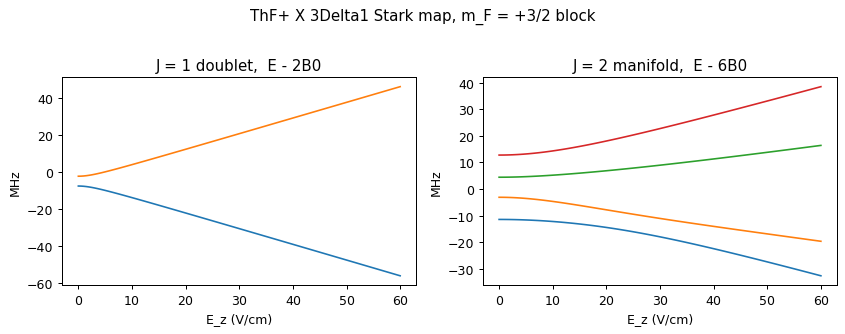

crossover field gam_F m_F d_mf E = w_ef/2 : 3.118 V/cm
half-splitting at 60 V/cm, model        : 50.9741 MHz
                two-level closed form   : 50.9636 MHz
active terms in this sweep: ('centrifugal', 'hyperfine_A_par', 'hyperfine_A_par_dJ1', 'omega_doubling', 'rotation', 'spin_rotation_cI', 'stark_z')
order = 'energy', gauge = 'none', reference index = 0


In [9]:
E = np.linspace(0.0, 60.0, 121)
res_E = sweep(tm, pset, {'E_z': E, 'B_z': np.zeros_like(E)})

fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.6))
for s in (0, 1):
    ax[0].plot(E, res_E.evals[:, s] - OFF, lw=1.3)
ax[0].set_title('J = 1 doublet,  E - 2B0')
for s in range(2, 6):
    ax[1].plot(E, res_E.evals[:, s] - 6 * pset.value('B0'), lw=1.3)
ax[1].set_title('J = 2 manifold,  E - 6B0')
for a in ax:
    a.set_xlabel('E_z (V/cm)')
    a.set_ylabel('MHz')
fig.suptitle('ThF+ X 3Delta1 Stark map, m_F = +3/2 block', y=1.02)
plt.tight_layout()
plt.show()

gam = lambda J, F, I=0.5: (J * (J + 1) + F * (F + 1) - I * (I + 1)) / (2 * F * (F + 1) * J * (J + 1))
d_mf = pset.value('d_mf')
Ecross = (wef / 2) / (gam(1, 1.5) * 1.5 * d_mf)
half = 0.5 * (res_E.evals[-1, 1] - res_E.evals[-1, 0])
two_level = np.hypot(gam(1, 1.5) * 1.5 * d_mf * 60.0, wef / 2)
print(f"crossover field gam_F m_F d_mf E = w_ef/2 : {Ecross:.3f} V/cm")
print(f"half-splitting at 60 V/cm, model        : {half:.4f} MHz")
print(f"                two-level closed form   : {two_level:.4f} MHz")
print("active terms in this sweep:", res_E.active_terms)
print(f"order = {res_E.order!r}, gauge = {res_E.gauge!r}, reference index = {res_E.reference}")

## 8. Zeeman maps, at zero field and at the operating field

We plot the shift from B = 0. This makes the Zeeman slope visible beside the
roughly 100 MHz Stark splitting.

The Zeeman operator is even under Ω → −Ω, but its ΔΩ = ±2 part enters the two
parity components with opposite sign, so the doublet components have different
g-factors already at E = 0: `Δg = g^u − g^ℓ = 2.74 × 10⁻⁴` at J = 1, F = 3/2,
which is `−2.88 kHz` across 0–5 G in the right panel. Turning the E field on
quenches most of that splitting and adds the Stark J-mixing contribution of
§12 with the opposite sign; at 60 V/cm the residual is `−0.82 kHz`.

E_z =   0.0 V/cm, level 0: dE over 0-5 G = +0.157866 MHz
E_z =   0.0 V/cm, level 1: dE over 0-5 G = +0.154989 MHz
E_z =  60.0 V/cm, level 0: dE over 0-5 G = +0.156835 MHz
E_z =  60.0 V/cm, level 1: dE over 0-5 G = +0.156019 MHz


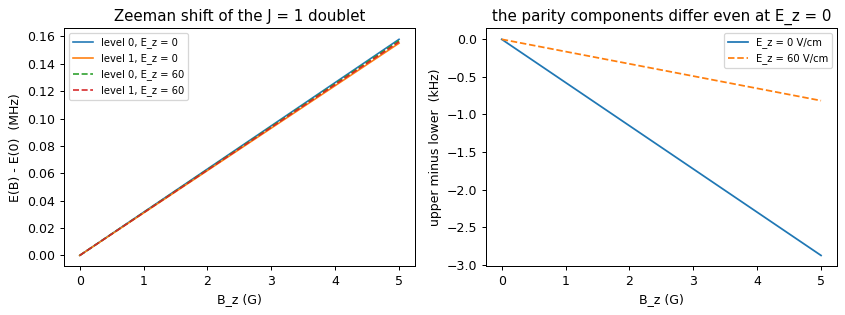

|g| mu_B B m_F at B = 5 G, |g| = 0.0149, m_F = 3/2: 0.156408 MHz


In [10]:
B = np.linspace(0.0, 5.0, 101)
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.6))
for Ez, ls in ((0.0, '-'), (60.0, '--')):
    r = sweep(tm, pset, {'E_z': np.full_like(B, Ez), 'B_z': B})
    shift = r.evals - r.evals[0]
    for s in (0, 1):
        ax[0].plot(B, shift[:, s], ls, lw=1.3, label=f'level {s}, E_z = {Ez:g}')
        print(f"E_z = {Ez:5.1f} V/cm, level {s}: dE over 0-5 G = {shift[-1, s]:+.6f} MHz")
    ax[1].plot(B, (shift[:, 1] - shift[:, 0]) * 1e3, ls, lw=1.4,
               label=f'E_z = {Ez:g} V/cm')
ax[0].set_ylabel('E(B) - E(0)  (MHz)')
ax[0].set_title('Zeeman shift of the J = 1 doublet')
ax[1].set_ylabel('upper minus lower  (kHz)')
ax[1].set_title('the parity components differ even at E_z = 0')
for a in ax:
    a.set_xlabel('B_z (G)')
    a.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f"|g| mu_B B m_F at B = 5 G, |g| = 0.0149, m_F = 3/2: "
      f"{0.0149 * heff.MU_B * 5 * 1.5:.6f} MHz")

## 9. A 2D (E, B) map

One `sweep` call covers all 2501 field points. Broadcasting produces the
Hamiltonians with a single `tensordot`, and `eigh` works through memory-sized
chunks. We again map only the Zeeman contribution,
`E(E_z, B_z) − E(E_z, 0)`, because the Stark shift is three orders of magnitude
larger. The remaining shift is linear in B and nearly flat in E_z: this level's
g-factor changes by only a fraction of a percent across 0–60 V/cm. Section 14
resolves that motion on a fractional scale, and the cell below prints its size.

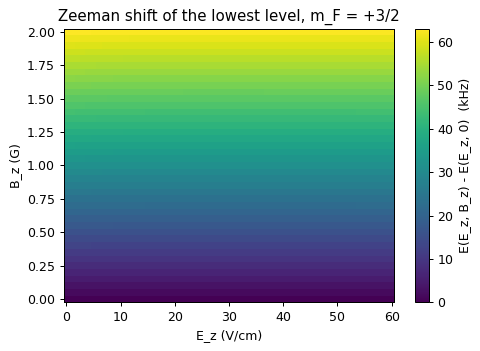

2501 field points x 14 levels, eigenvectors kept: (2501, 14, 14)
Zeeman shift at B_z = 2 G:  63.1464 kHz at E_z = 0,  62.7341 kHz at E_z = 60 V/cm  (-0.653 %)


In [11]:
Eg, Bg = np.meshgrid(np.linspace(0, 60, 61), np.linspace(0, 2, 41), indexing='ij')
res2 = sweep(tm, pset, {'E_z': Eg.ravel(), 'B_z': Bg.ravel()}, chunk=512)
lvl = res2.evals[:, 0].reshape(Eg.shape)
zeeman = (lvl - lvl[:, :1]) * 1e3        # shift from B_z = 0, in kHz

plt.figure(figsize=(5.5, 4))
plt.pcolormesh(Eg, Bg, zeeman, shading='auto')
plt.colorbar(label='E(E_z, B_z) - E(E_z, 0)  (kHz)')
plt.xlabel('E_z (V/cm)')
plt.ylabel('B_z (G)')
plt.title('Zeeman shift of the lowest level, m_F = +3/2')
plt.tight_layout()
plt.show()
print(f"{res2.evals.shape[0]} field points x {res2.evals.shape[1]} levels, "
      f"eigenvectors kept: {res2.evecs.shape}")
print(f"Zeeman shift at B_z = 2 G:  {zeeman[0, -1]:.4f} kHz at E_z = 0,  "
      f"{zeeman[-1, -1]:.4f} kHz at E_z = 60 V/cm  "
      f"({(zeeman[-1, -1] / zeeman[0, -1] - 1) * 100:+.3f} %)")

## 10. Levels at an arbitrary field

In [12]:
def display_levels(tm_, pset_, knobs, n=6):
    H = hamiltonian(tm_, pset_, knobs)
    w, v = np.linalg.eigh(H)
    Pop = parity_operator(tm_.kets, ctx.S, ell=0.0, s=0.0)
    print("  #        E - 2B0 (MHz)   <P>     dominant ket")
    for s in range(n):
        par = float(np.real(np.vdot(v[:, s], Pop @ v[:, s])))
        dom_ = tm_.kets[np.argmax(np.abs(v[:, s]))]
        print(f" {s:2d}   {w[s] - OFF:16.6f}  {par:+.3f}   {gen_state_str(dom_)}")


display_levels(tm, pset, {'E_z': 24.0, 'B_z': 1.0})

  #        E - 2B0 (MHz)   <P>     dominant ket
  0         -25.543642  -0.129   |J=1, Om=+1, F=1.5, mF=+1.5>
  1          15.522745  +0.129   |J=1, Om=-1, F=1.5, mF=+1.5>
  2       29081.658645  +0.625   |J=2, Om=+1, F=2.5, mF=+1.5>
  3       29088.232756  +0.639   |J=2, Om=+1, F=1.5, mF=+1.5>
  4       29105.033424  -0.741   |J=2, Om=-1, F=2.5, mF=+1.5>
  5       29117.229415  -0.524   |J=2, Om=-1, F=1.5, mF=+1.5>


## 11. g-factors and induced dipoles from exact derivatives

Both `g = −(∂E/∂B_z)/(μ_B m_F)` and `d_eff = −∂E/∂E_z` come from the same
Hellmann–Feynman kernel. Because `∂H/∂knob` is already a sum of catalogue
matrices, we need neither a field step nor a finite-difference subtraction.

The Zeeman operator is `H_Z = μ_B B·G·J` with the body-frame tensor
`G = diag(G_xx, G_yy, G_zz)`, so at zero field the two parity components of a
doublet have different g-factors:

`g_J(e/f) = −G⊥ − (G_zz − G⊥)/[J(J+1)] ± G_Δ`, with the `+` on `e`,

`G⊥ = (G_xx + G_yy)/2`, `G_Δ = (G_xx − G_yy)/2`, and
`g_F = g_J [F(F+1)+J(J+1)−I(I+1)]/[2F(F+1)] + g_N (μ_N/μ_B) κ_F`.
Only the sum `G_zz + G⊥ = 0.04756` is measured. `d_eff = 0` at zero field
because the unpolarised doublet has no space-fixed dipole; at 60 V/cm `d_eff`
approaches the fully polarised `γ_F m_F d_mf`.

In [13]:
gam_ = gam(1, 1.5)
kap = lambda J, F, I=0.5: (F * (F + 1) - J * (J + 1) + I * (I + 1)) / (2 * F * (F + 1))
G_perp = 0.5 * (pset.value('G_xx') + pset.value('G_yy'))
G_Delta = 0.5 * (pset.value('G_xx') - pset.value('G_yy'))
proj = (1.5 * 2.5 + 1 * 2 - 0.5 * 1.5) / (2 * 1.5 * 2.5)
nuc = pset.value('g_N') * (heff.MU_N / heff.MU_B) * kap(1, 1.5)
closed_e = (-G_perp - (pset.value('G_zz') - G_perp) / 2 + G_Delta) * proj + nuc
closed_f = (-G_perp - (pset.value('G_zz') - G_perp) / 2 - G_Delta) * proj + nuc

res_g0 = g_factors(tm, pset, {'E_z': 0.0, 'B_z': 0.0}, ctx=ctx)
res_g60 = g_factors(tm, pset, {'E_z': 60.0, 'B_z': 0.0}, ctx=ctx)

print(f"model  g(J=1, F=3/2) = {res_g0['g'][0]:+.7f}   "
      f"({abs(res_g0['g'][0]) * heff.MU_B * 1e3:.3f} kHz/G)")
print(f"closed form, e level = {closed_e:+.7f}   ({abs(closed_e) * heff.MU_B * 1e3:.3f} kHz/G)")
print(f"closed form, f level = {closed_f:+.7f}   ({abs(closed_f) * heff.MU_B * 1e3:.3f} kHz/G)")
print(f"measured |g|         =  0.0149(3)     (20.85 kHz/G)  [Ng 2022 Table I; sign not measured]")
print()
print(f"d_eff at   0 V/cm    = {res_g0['d_eff'][:4].round(6)} MHz/(V/cm)")
print(f"d_eff at  60 V/cm    = {res_g60['d_eff'][:4].round(6)} MHz/(V/cm)")
print(f"fully polarised gam_F m_F d_mf = {gam_ * 1.5 * d_mf:.6f} MHz/(V/cm)")
print()
print("m_F of this block:", res_g0['mF'], " conventions:", res_g0['conventions']['zeeman_energy'])

model  g(J=1, F=3/2) = -0.0150389   (21.049 kHz/G)
closed form, e level = -0.0150358   (21.044 kHz/G)
closed form, f level = -0.0147617   (20.661 kHz/G)
measured |g|         =  0.0149(3)     (20.85 kHz/G)  [Ng 2022 Table I; sign not measured]

d_eff at   0 V/cm    = [ 0. -0. -0. -0.] MHz/(V/cm)
d_eff at  60 V/cm    = [ 0.849058 -0.845499  0.530931  0.276353] MHz/(V/cm)
fully polarised gam_F m_F d_mf = 0.848249 MHz/(V/cm)

m_F of this block: 1.5  conventions: E_minus_g_muB_B_mF


## 12. The differential g-factor Δg

The two components of the J = 1, F = 3/2 doublet differ in g for two reasons.
At zero field the `G_Δ` part of the Zeeman tensor enters them with opposite
sign (§8). Under an E field they also acquire different J = 2 admixtures
through the Stark ΔJ = ±1 element, which contributes with the opposite sign and
dominates at the operating field. The difference is an important systematic in
the eEDM experiment. We evaluate the named pair with `pair_differential`, which
preserves its sign and records which of the two circulating definitions was
used.

Two caveats bound how much the number below proves. The basis omits the ³Δ₂
coupling ([HAM] §1.2), and `G_Δ` is a second-order estimate carrying roughly
20 %. In the axial-only limit `G_xx = G_yy` this model gives −0.00213, next to
Ng's axial 32-level −0.00223; `G_Δ` then carries it to −0.00261 against a
measured −0.00255(6). Both caveats are larger than that residual, so the
agreement is not a test of either.

Delta = g^u - g^l  [Petrov arXiv:2503.02840 Eq. 18; Ng 2022 paper]


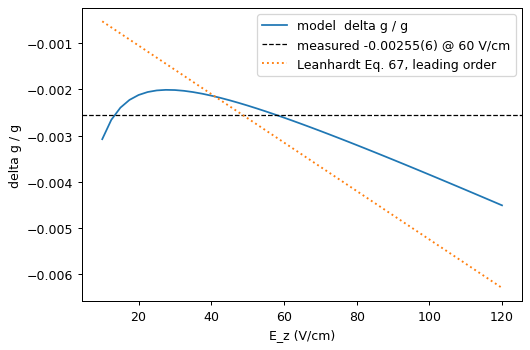

model  delta g / g at 60 V/cm = -0.00261
       Delta g   at 60 V/cm   = +7.779e-05
Ng 32-level model             = -0.00223      measured = -0.00255(6)
Leanhardt Eq. 67 at 60 V/cm   = -0.00315


In [14]:
Es = np.linspace(10.0, 120.0, 45)
g_all = np.array([g_factors(tm, pset, {'E_z': float(e), 'B_z': 0.0}, ctx=ctx)['g']
                  for e in Es])
gl, gu = g_all[:, 0], g_all[:, 1]          # lower and upper Stark doublet component
dg, label = pair_differential(gu, gl, pset.conventions)
gbar = 0.5 * (gu + gl)
print(label)

plt.figure(figsize=(6, 4))
plt.plot(Es, 0.5 * dg / gbar, lw=1.4, label='model  delta g / g')
plt.axhline(-0.00255, ls='--', c='k', lw=1, label='measured -0.00255(6) @ 60 V/cm')
plt.plot(Es, -9 * d_mf * Es / (40 * pset.value('B0')), ':',
         label='Leanhardt Eq. 67, leading order')
plt.xlabel('E_z (V/cm)')
plt.ylabel('delta g / g')
plt.legend()
plt.tight_layout()
plt.show()

print(f"model  delta g / g at 60 V/cm = {np.interp(60.0, Es, 0.5 * dg / gbar):+.5f}")
print(f"       Delta g   at 60 V/cm   = {np.interp(60.0, Es, dg):+.3e}")
print(f"Ng 32-level model             = -0.00223      measured = -0.00255(6)")
print(f"Leanhardt Eq. 67 at 60 V/cm   = {-9 * d_mf * 60 / (40 * pset.value('B0')):+.5f}")

## 13. PT-odd shifts

We use `H_PT = −(d_e E_eff + W_TP k_TP) Ω/|Ω|` (Ng Eq. C.8), with no
Leanhardt ½, as selected by `edm_factor='ng'`. The sign of Ω is fixed by `n_hat='F_to_Th'`,
i.e. n̂ points from F to Th. The observable in the experiment is
`f^BD = 2 d_e E_eff`.

Both PT-odd terms are off in `thf_v1()` (`d_e = k_TP = 0`). We can still inspect
their response through the matrix `−Ω/|Ω|`. We plot its first-order expectation
value `⟨ψ|M|ψ⟩` on the Stark
eigenstates: it runs from 0 at zero field to ∓1 when the doublet is fully
polarised, and multiplying it by `d_e E_eff` gives the shift. Taking the shift
as an eigenvalue difference instead would put a 35 µHz number on top of a
14.5 GHz rotational energy (within a factor of ~30 of float64 resolution).
The expectation value avoids subtracting these nearly equal energies.

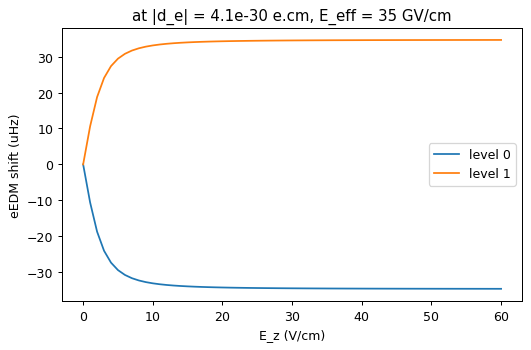

convention: edm_factor = 'ng', n_hat = 'F_to_Th' (n_hat points from F to Th)
<-Omega/|Omega|> at 60 V/cm, levels 0 and 1: [-0.99865  0.99865]   (at 0 V/cm: [-0.  0.])
d_e E_eff at the bound      = 34.7 uHz;   f^BD = 2 d_e E_eff = 69.4 uHz
W_TP k_TP at k_TP = 1e-9    = 50.0 uHz


In [15]:
M_edm = tm.mats[tm.names.index('pt_odd_edm')]        # the parameter-free -Omega/|Omega|
Ep = np.linspace(0.0, 60.0, 61)
rp = sweep(tm, pset, {'E_z': Ep, 'B_z': np.zeros_like(Ep)})
om = np.real(expectation(rp.evecs, M_edm))

d_e_bound = 4.1e-30                     # |d_e| 90% bound, Roussy 2023 (HfF+), e.cm
uHz = d_e_bound * pset.value('E_eff') * 1e12       # MHz -> uHz

plt.figure(figsize=(6, 4))
for s in (0, 1):
    plt.plot(Ep, om[:, s] * uHz, lw=1.4, label=f'level {s}')
plt.xlabel('E_z (V/cm)')
plt.ylabel('eEDM shift (uHz)')
plt.title('at |d_e| = 4.1e-30 e.cm, E_eff = 35 GV/cm')
plt.legend()
plt.tight_layout()
plt.show()

print(f"convention: edm_factor = {pset.conventions.edm_factor!r}, "
      f"n_hat = {pset.conventions.n_hat!r} (n_hat points from F to Th)")
print(f"<-Omega/|Omega|> at 60 V/cm, levels 0 and 1: {om[-1, :2].round(5)}   "
      f"(at 0 V/cm: {om[0, :2].round(5)})")
print(f"d_e E_eff at the bound      = {uHz:.1f} uHz;   f^BD = 2 d_e E_eff = {2 * uHz:.1f} uHz")
print(f"W_TP k_TP at k_TP = 1e-9    = {pset.value('W_TP') * 1e-9 * 1e12:.1f} uHz")

## 14. g-factor vs field

We now evaluate the same derivatives across the field sweep. Levels are ordered
by energy at each field point. The two J = 1 components (0 and 1) never cross
here, but the J = 2 slots rearrange, so their labels can change state character.

The left panel plots all six levels on one g-factor axis, where the J = 1
pair's motion is smaller than a pixel (§9 gives the fractional scale).
The right panel isolates levels 0 and 1 and plots the fractional
change `(g − g(E_ref)) / |g(E_ref)|` relative to `E_ref = 10 V/cm` (the first
field point, past the low-field polarisation knee), which resolves the ∓0.14 %
opposite-signed motion that is Δg.

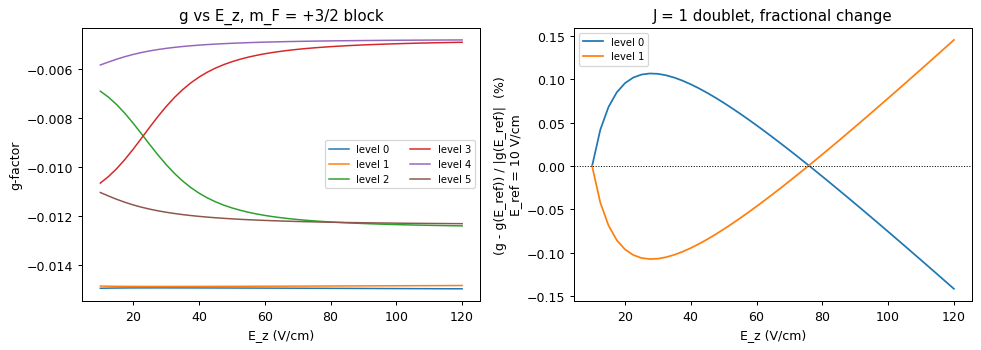

the two J = 1 components move by about 0.14 % across 10-120 V/cm, in opposite directions -- that opposite motion is Delta g:
  level 0: -0.0149477 -> -0.0149689   (-0.141 %)
  level 1: -0.0148560 -> -0.0148345   (+0.145 %)


In [16]:
E_ref = Es[0]                                        # 10 V/cm, first field point (past the polarisation knee)
g_ref = g_all[0, :2]
frac_pct = (g_all[:, :2] - g_ref) / np.abs(g_ref) * 100     # levels 0, 1 only

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for s in range(6):
    ax[0].plot(Es, g_all[:, s], lw=1.2, label=f'level {s}')
ax[0].set_xlabel('E_z (V/cm)')
ax[0].set_ylabel('g-factor')
ax[0].set_title('g vs E_z, m_F = +3/2 block')
ax[0].legend(fontsize=8, ncol=2)

for s in (0, 1):
    ax[1].plot(Es, frac_pct[:, s], lw=1.4, label=f'level {s}')
ax[1].axhline(0.0, ls=':', c='k', lw=0.8)
ax[1].set_xlabel('E_z (V/cm)')
ax[1].set_ylabel(f'(g - g(E_ref)) / |g(E_ref)|  (%)\nE_ref = {E_ref:.0f} V/cm')
ax[1].set_title('J = 1 doublet, fractional change')
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print("the two J = 1 components move by about 0.14 % across 10-120 V/cm, "
      "in opposite directions -- that opposite motion is Delta g:")
for s in (0, 1):
    print(f"  level {s}: {g_all[0, s]:+.7f} -> {g_all[-1, s]:+.7f}   "
          f"({(g_all[-1, s] - g_all[0, s]) / abs(g_all[0, s]) * 100:+.3f} %)")

## 15. E1 line strengths, J = 1 → 2

We calculate transition dipoles between two separately diagonalised m_F blocks:
m_F = +1/2 → +3/2, so the 3j selection rule `m_bra = m_ket + p` picks
p = −1. Amplitudes are summed over polarisation and then squared, so
intensity-borrowing paths interfere; strengths come out in units of `d_mf²`.

At zero field, parity is exact and every line below connects
opposite parities, as E1 requires. Labels come from `label_lines`, which reads
the dominant (J, F) and the superposition parity off each eigenvector;
`line_strengths` never sees them, so labelling does not decide which
transitions get computed.

62 lines above 1e-6 of the strongest; 0 of them connect the same parity

J = 1 -> 2, offsets from 4B0 = 29097.330 MHz:
    -10.4471 MHz   S = 0.2501 d_mf^2   J=1 F=0.5 e (-1)  ->  J=2 F=1.5 e (+1)
     -3.7292 MHz   S = 0.1800 d_mf^2   J=1 F=1.5 e (-1)  ->  J=2 F=2.5 e (+1)
     +0.1329 MHz   S = 0.2501 d_mf^2   J=1 F=0.5 f (+1)  ->  J=2 F=1.5 f (-1)
     +4.6005 MHz   S = 0.0200 d_mf^2   J=1 F=1.5 e (-1)  ->  J=2 F=1.5 e (+1)
     +6.8508 MHz   S = 0.1800 d_mf^2   J=1 F=1.5 f (+1)  ->  J=2 F=2.5 f (-1)
    +15.1805 MHz   S = 0.0200 d_mf^2   J=1 F=1.5 f (+1)  ->  J=2 F=1.5 f (-1)


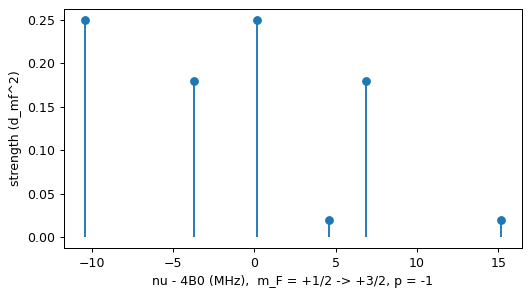

In [17]:
knobs0 = {'E_z': 0.0, 'B_z': 0.0}
wa, va = np.linalg.eigh(hamiltonian(tm_h, pset, knobs0))
wb, vb = np.linalg.eigh(hamiltonian(tm, pset, knobs0))
freqs, S = line_strengths(wa, va, sub_h, wb, vb, sub, ctx,
                          polarizations=(-1,), weights={-1: 1.0})
lab_a = label_lines(sub_h, va, ctx.S, rule=pset.conventions.ef_rule, ell=0.0, s=0.0)
lab_b = label_lines(sub, vb, ctx.S, rule=pset.conventions.ef_rule, ell=0.0, s=0.0)

mask = S > 1e-6 * S.max()
ia, ib = np.nonzero(mask)
same_parity = sum(1 for i, j in zip(ia, ib) if lab_a[i]['parity'] == lab_b[j]['parity'])
print(f"{mask.sum()} lines above 1e-6 of the strongest; "
      f"{same_parity} of them connect the same parity")

rows = sorted(((freqs[i, j], S[i, j], lab_a[i], lab_b[j]) for i, j in zip(ia, ib)
               if lab_a[i]['J'] == 1.0 and lab_b[j]['J'] == 2.0))
FOUR_B0 = 4 * pset.value('B0')
print(f"\nJ = 1 -> 2, offsets from 4B0 = {FOUR_B0:.3f} MHz:")
for f, s_, la, lb in rows:
    print(f"  {f - FOUR_B0:+10.4f} MHz   S = {s_:.4f} d_mf^2   "
          f"J=1 F={la['F']:.1f} {la['ef']} ({la['parity']:+d})  ->  "
          f"J=2 F={lb['F']:.1f} {lb['ef']} ({lb['parity']:+d})")

plt.figure(figsize=(6, 3.4))
plt.stem([f - FOUR_B0 for f, _, _, _ in rows], [s_ for _, s_, _, _ in rows], basefmt=' ')
plt.xlabel(f'nu - 4B0 (MHz),  m_F = +1/2 -> +3/2, p = -1')
plt.ylabel('strength (d_mf^2)')
plt.tight_layout()
plt.show()

## 16. A sweep over 200 parameter sets

We can vary molecular parameters just as we varied the fields. The coefficients
are broadcast into `c[200, n_terms]`, a single `tensordot` assembles the
Hamiltonians, and `eigh` diagonalises the batch. The matrices stay fixed while
`A_par` and `omega_ef` change, just as they did for `E_z` and `B_z`.

Two observables from the same 200 diagonalisations, in the m_F = +1/2 block:
the J = 1, F = 3/2 Ω-doublet splitting, which tracks `ω_ef` and is flat in A∥;
and the J = 1 hyperfine interval, which tracks A∥ and is flat in `ω_ef`.

coefficient matrix : (200, 13)
batched Hamiltonians: (200, 16, 16)
eigenvalues         : (200, 16)


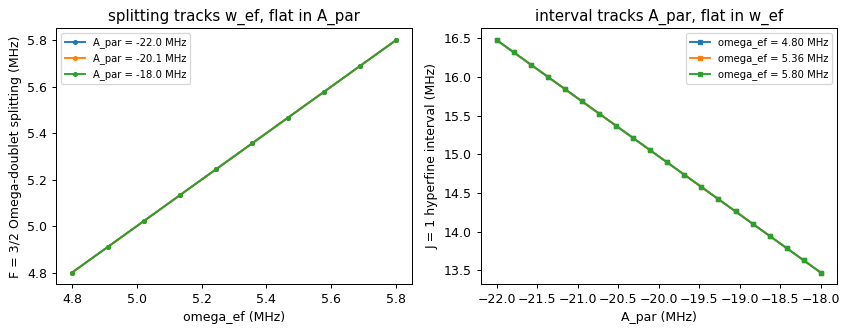

spread of the doublet splitting across all 20 A_par values at fixed w_ef: 6.80e-07 MHz
spread of the hyperfine interval across all 10 w_ef values at fixed A_par: 1.58e-10 MHz
hyperfine interval at A_par = -20 MHz  (closed form (3/4)|A| - (3/2)c_I = 14.9700): 14.9726 MHz


In [18]:
A_vals = np.linspace(-22.0, -18.0, 20)
w_vals = np.linspace(4.8, 5.8, 10)
Ag, Wg = np.meshgrid(A_vals, w_vals, indexing='ij')
zeros = np.zeros(Ag.size)

c = sweep_coefficients(tm_h, pset, {'A_par': Ag.ravel(), 'omega_ef': Wg.ravel(),
                                    'E_z': zeros, 'B_z': zeros})
print('coefficient matrix :', c.shape)
Hb = hamiltonian_batch(tm_h, c)
print('batched Hamiltonians:', Hb.shape)
wb2, _ = eigh_batch(Hb, chunk=256)
print('eigenvalues         :', wb2.shape)

doublet = (wb2[:, 1] - wb2[:, 0]).reshape(Ag.shape)
hf = (0.5 * (wb2[:, 2] + wb2[:, 3]) - 0.5 * (wb2[:, 0] + wb2[:, 1])).reshape(Ag.shape)

fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.8))
for i in (0, 9, 19):
    ax[0].plot(w_vals, doublet[i], marker='o', ms=3, label=f'A_par = {A_vals[i]:.1f} MHz')
ax[0].set_xlabel('omega_ef (MHz)')
ax[0].set_ylabel('F = 3/2 Omega-doublet splitting (MHz)')
ax[0].set_title('splitting tracks w_ef, flat in A_par')
ax[0].legend(fontsize=8)
for j in (0, 5, 9):
    ax[1].plot(A_vals, hf[:, j], marker='s', ms=3, label=f'omega_ef = {w_vals[j]:.2f} MHz')
ax[1].set_xlabel('A_par (MHz)')
ax[1].set_ylabel('J = 1 hyperfine interval (MHz)')
ax[1].set_title('interval tracks A_par, flat in w_ef')
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"spread of the doublet splitting across all 20 A_par values at fixed w_ef: "
      f"{np.ptp(doublet[:, 0]):.2e} MHz")
print(f"spread of the hyperfine interval across all 10 w_ef values at fixed A_par: "
      f"{np.ptp(hf[0, :]):.2e} MHz")
print(f"hyperfine interval at A_par = -20 MHz  (closed form (3/4)|A| - (3/2)c_I = "
      f"{0.75 * 20 - 1.5 * cI:.4f}): {np.interp(-20.0, A_vals, hf[:, 0]):.4f} MHz")

## 17. Model scope

The model includes nine Hamiltonian terms plus an opt-in PT-odd pair: rotation,
centrifugal distortion, Ω-doubling, axial hyperfine ΔJ = 0 and ΔJ = ±1 (one
parameter, A∥, for both), nuclear spin–rotation `c_I`, Stark, the three
body-frame Zeeman components `G_zz`, `G_xx`, `G_yy`, nuclear Zeeman; then
`pt_odd_edm` and `pt_odd_scalar_pseudoscalar`.

The following interactions are omitted (scales from [HAM] §5):

- Ω = ±2, ±3 (³Δ₂, ³Δ₃): mixing ≤ 1.4 × 10⁻³, energy effect linear in J(J+1)
  and therefore absorbed into B₀; residual ≤ 38 Hz at J = 4. Omitting it accounts
  for the 15 % discrepancy in δg discussed in §12.
- `e_Δ`, the hyperfine-dependent Ω-doubling: 1–10 kHz estimate, the only
  dropped term above the kHz line (OPEN-8).
- Rotating-frame `ħω_rot F_x`: not a static-field term, and it breaks m_F
  blocking.

`c_I = 20 kHz` is an analogy-based sensitivity
estimate: its sign and accuracy in ThF⁺ are not established, and no universal
numeric uncertainty bound is assigned (OPEN-6). The sign of g_F is not
measured, only |g| (OPEN-4); E_eff is 35 vs 37.3 GV/cm across sources
(OPEN-14).

For the conventions and parameter limits, see [the model guide](../docs/models.md)
and [scientific limitations](../docs/open-questions.md):

- The upper Ω-doublet component has parity `−(−1)^J` in the implemented
  convention, i.e. f above e; §5 explains its relation to the e/f labels.
- The [HAM] §2.8 g_F table uses the same three Zeeman parameters as the code,
  `G_zz = 0.046532`, `G_xx = 8.2211e−4`, `G_yy = 1.23327e−3`. §11
  demonstrates their agreement with the adopted |g| = 0.0149 scale.

`tests/` check kernel behavior and symmetry identities; comparisons to
published numbers are opt-in behind `HEFF_RUN_LITERATURE=1`. These checks
support software consistency, not a claim that the effective Hamiltonian is
physically complete.